In [22]:
install.packages("tm", dependencies = TRUE)
install.packages("ggplot2")
install.packages("e1071")
install.packages("caret")
install.packages("tidyverse")



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“dependencies ‘Rcampdf’, ‘Rgraphviz’, ‘tm.lexicon.GeneralInquirer’ are not available”
also installing the dependencies ‘qpdf’, ‘antiword’, ‘filehash’, ‘pdftools’, ‘Rpoppler’, ‘SnowballC’


Warning message in install.packages("tm", dependencies = TRUE):
“installation of package ‘Rpoppler’ had non-zero exit status”
Warning message in install.packages("tm", dependencies = TRUE):
“installation of package ‘pdftools’ had non-zero exit status”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [23]:
library(tm)
library(ggplot2)
library(e1071)
library(caret)
library(tidyverse)

Loading required package: NLP


Attaching package: ‘NLP’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element


Loading required package: lattice

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ NLP::annotate()  masks ggplot2::annotate()
✖ e1071::element() masks ggplot2::element()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ purrr::lift()    masks caret::lift()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [24]:
data <- read.csv("Mobile Reviews Sentiment.csv", stringsAsFactors = FALSE)


In [25]:
print(names(data))

 [1] "review_id"            "customer_name"        "age"                 
 [4] "brand"                "model"                "price_usd"           
 [7] "price_local"          "currency"             "exchange_rate_to_usd"
[10] "rating"               "review_text"          "sentiment"           
[13] "country"              "language"             "review_date"         
[16] "verified_purchase"    "battery_life_rating"  "camera_rating"       
[19] "performance_rating"   "design_rating"        "display_rating"      
[22] "review_length"        "word_count"           "helpful_votes"       
[25] "source"              


In [26]:
text_col <- grep("text", names(data), ignore.case = TRUE, value = TRUE)[1]
sent_col <- grep("sentiment", names(data), ignore.case = TRUE, value = TRUE)[1]
cat("Detected text column:", text_col, "\n")
cat("Detected sentiment column:", sent_col, "\n")

Detected text column: review_text 
Detected sentiment column: sentiment 


In [27]:
data <- data[, c(text_col, sent_col)]
colnames(data) <- c("Text", "Sentiment")

In [28]:
head(data)
table(data$Sentiment)

,Text,Sentiment
,<chr>,<chr>
1,Not worth the money spent. Wouldn’t recommend.,Negative
2,Absolutely love this phone! The camera is next level. Absolutely worth it!,Positive
3,Loving the clean UI and fast updates. Loving it so far!,Positive
4,Build quality feels solid and durable. No regrets buying this one.,Positive
5,Not bad for daily use but could be optimized. Average experience overall.,Neutral
6,Battery easily lasts a day with heavy use. No regrets buying this one.,Positive



Negative  Neutral Positive 
    9911    12549    27540 

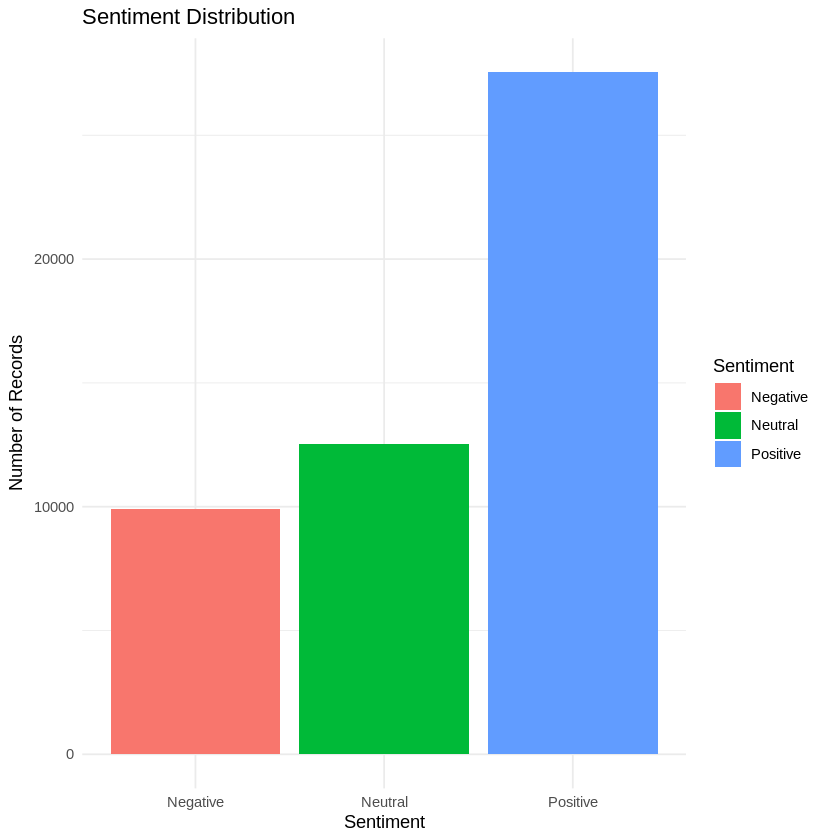

In [29]:
ggplot(data, aes(x = Sentiment, fill = Sentiment)) +
  geom_bar() +
  theme_minimal() +
  ggtitle("Sentiment Distribution") +
  xlab("Sentiment") + ylab("Number of Records")

In [30]:
corpus <- VCorpus(VectorSource(data$Text))
corpus <- tm_map(corpus, content_transformer(tolower))
corpus <- tm_map(corpus, removePunctuation)
corpus <- tm_map(corpus, removeNumbers)
corpus <- tm_map(corpus, removeWords, stopwords("english"))
corpus <- tm_map(corpus, stripWhitespace)

In [35]:
dtm <- DocumentTermMatrix(corpus)
dtm <- removeSparseTerms(dtm, 0.99)
df <- as.data.frame(as.matrix(dtm))
df$Sentiment <- as.factor(data$Sentiment)

In [36]:
set.seed(123)
trainIndex <- createDataPartition(df$Sentiment, p = 0.7, list = FALSE)
trainData <- df[trainIndex, ]
testData <- df[-trainIndex, ]

In [37]:
model <- naiveBayes(Sentiment ~ ., data = trainData)


In [38]:
pred <- predict(model, newdata = testData)


In [39]:
conf_mat <- confusionMatrix(pred, testData$Sentiment)
print(conf_mat)

Confusion Matrix and Statistics

          Reference
Prediction Negative Neutral Positive
  Negative     2973       0     1997
  Neutral         0    3764     2963
  Positive        0       0     3302

Overall Statistics
                                          
               Accuracy : 0.6693          
                 95% CI : (0.6617, 0.6768)
    No Information Rate : 0.5508          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.5279          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Negative Class: Neutral Class: Positive
Sensitivity                   1.0000         1.0000          0.3997
Specificity                   0.8339         0.7363          1.0000
Pos Pred Value                0.5982         0.5595          1.0000
Neg Pred Value                1.0000         1.0000          0.5760
Prevalence                   

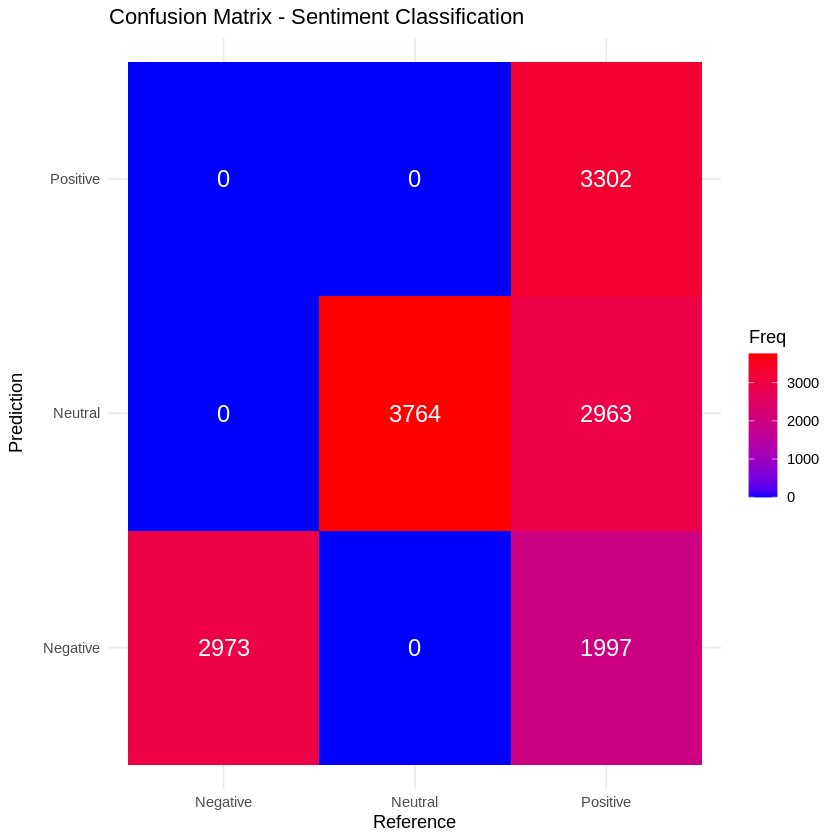

In [40]:
cm_df <- as.data.frame(conf_mat$table)
ggplot(cm_df, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), color = "white", size = 5) +
  scale_fill_gradient(low = "blue", high = "red") +
  theme_minimal() +
  ggtitle("Confusion Matrix - Sentiment Classification")